In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Загрузка исторических данных

name = "BTCUSDT_1h_last_year"
filename = f"data/1h_last_year/{name}.csv"
data = pd.read_csv(filename, parse_dates=['timestamp'])
data.set_index('timestamp', inplace=True)
data.drop(['high', 'low', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume', 'ignore'], axis=1, inplace=True)

In [4]:
# Стратегия

short_window = 200
long_window = 50

data['SMA200'] = data['close'].rolling(window=short_window).mean()
data['SMA50'] = data['close'].rolling(window=long_window).mean()

# Сигналы: 1 = покупка, -1 = продажа, 0 = держать
data['signal'] = 0
data.loc[(data['SMA50'] >= data['SMA200']) & (data['SMA50'].shift(1) <= data['SMA200'].shift(1)), 'signal'] = 1
data.loc[(data['SMA50'] <= data['SMA200']) & (data['SMA50'].shift(1) >= data['SMA200'].shift(1)), 'signal'] = -1

In [5]:
# Бэктестинг

initial_cash = 100000 # стартовый капитал
cash = initial_cash # свободные деньги (зафиксированы)
investments = 0 # деньги в активах (могут меняться)

commission = 0.000  # 0.0% комиссия
#trade_fraction = 0.1  # 10% от портфеля на одну сделку
trade_amount = 10000 # фикс сумма на сделку

def func(initial_cash, cash, investments, commission, trade_amount):

    portfolio_values = [initial_cash]
    positions = []  # список открытых позиций
    trade_log = []

    for i in range(1, len(data)):
        price = data['open'].iloc[i]
        signal = data['signal'].iloc[i - 1]

        # --- Покупка ---
        if signal == 1 and cash >= trade_amount:
            #trade_amount = cash * trade_fraction
            position_size = trade_amount / price
            cash -= trade_amount + trade_amount * commission
            positions.append({'size': position_size, 'price': price})
            investments = sum([p['size'] * price for p in positions])
            portfolio_value = cash + investments
            trade_log.append({'date': data.index[i], 'type': 'buy', 'position_size': position_size, 'price': price,
                'investments': investments, 'cash': cash, 'portfolio': portfolio_value, 'PnL': 0})

        # --- Продажа (закрываем только одну позицию) ---
        elif signal == -1 and len(positions) > 0:
            pos = positions.pop(0)  # FIFO — закрываем первую открытую сделку
            PnL = pos['size'] * price - pos['size'] * pos['price']
            cash += pos['size'] * price
            cash -= pos['size'] * price * commission
            investments = sum([p['size'] * price for p in positions])
            portfolio_value = cash + investments
            trade_log.append({'date': data.index[i], 'type': 'sell', 'position_size': pos['size'], 'price': price,
                'investments': investments, 'cash': cash, 'portfolio': portfolio_value, 'PnL': PnL})

    return trade_log

#     # Текущая стоимость портфеля = наличные + все открытые позиции по текущей цене
#     portfolio_value = cash + sum([p['size'] * price for p in positions])
#     portfolio_values.append(portfolio_value)
#
# data['portfolio'] = portfolio_values
# data['open_positions'] = [len(positions) for _ in range(len(data))]


In [6]:
data

,open,close,volume,SMA200,SMA50,signal
timestamp,,,,,,
2025-03-11 22:00:00,83110.71,83133.48,560.56990,NaN,NaN,0
2025-03-11 23:00:00,83133.48,82932.99,780.17427,NaN,NaN,0
2025-03-12 00:00:00,82932.99,82765.52,658.58485,NaN,NaN,0
2025-03-12 01:00:00,82765.52,83313.60,1260.16624,NaN,NaN,0
2025-03-12 02:00:00,83313.60,82430.79,1790.05082,NaN,NaN,0
...,...,...,...,...,...,...
2026-03-11 17:00:00,70570.71,70785.99,2122.20651,69351.94450,69898.7322,0
2026-03-11 18:00:00,70785.99,70617.64,1134.13411,69370.73120,69931.8826,0
2026-03-11 19:00:00,70617.63,70641.82,644.23151,69388.80725,69972.7048,0


In [7]:
import time

start_time = time.perf_counter()  # или time.time()
trade_log = func(initial_cash, cash, investments, commission, trade_amount)
end_time = time.perf_counter()

print(f"Время выполнения: {end_time - start_time:.6f} секунд")

Время выполнения: 0.171681 секунд


In [6]:
trade_log_df = pd.DataFrame(trade_log).set_index('date')
trade_log_df

,type,position_size,price,investments,cash,portfolio,PnL
date,,,,,,,
2025-04-03 08:00:00,buy,0.119823,83456.76,10000.0,90000.000000,100000.000000,0.000000
2025-04-03 18:00:00,sell,0.119823,81830.01,0.0,99805.078702,99805.078702,-194.921298
2025-04-06 04:00:00,buy,0.119984,83344.14,10000.0,89805.078702,99805.078702,0.000000
2025-04-06 12:00:00,sell,0.119984,82855.99,0.0,99746.508297,99746.508297,-58.570405
2025-04-06 15:00:00,buy,0.120967,82667.08,10000.0,89746.508297,99746.508297,0.000000
...,...,...,...,...,...,...,...
2026-02-26 18:00:00,buy,0.149641,66826.80,10000.0,90905.319458,100905.319458,0.000000
2026-02-28 10:00:00,sell,0.149641,63658.55,0.0,100431.220743,100431.220743,-474.098715
2026-03-02 12:00:00,buy,0.150694,66359.67,10000.0,90431.220743,100431.220743,0.000000


In [ ]:
# filename = f"logs/{name}_trade_log.csv"
# trade_log_df.to_csv(filename, index=False)
# print(f"\nДанные сохранены в файл: {filename}")

In [70]:
# Анализ результатов

# Подсчёт прибыльных и убыточных сделок
profits = []
for i in range(0, len(trade_log_df)-1, 2):
    buy = trade_log_df.iloc[i]['price']
    sell = trade_log_df.iloc[i + 1]['price']
    profits.append(sell - buy)
profits = np.array(profits)
num_trades = len(profits)
num_wins = np.sum(profits > 0)
win_rate = num_wins / num_trades * 100 if num_trades > 0 else 0

# Максимальная просадка
portfolio_array = np.array(portfolio_values)
running_max = np.maximum.accumulate(portfolio_array)
drawdown = (running_max - portfolio_array) / running_max
max_drawdown = np.max(drawdown) * 100

total_return = (portfolio_values[-1] - initial_cash) / initial_cash * 100

In [71]:
# --- 5. Вывод статистики ---
print(f"Общая доходность: {total_return:.2f}%")
print(f"Количество сделок: {num_trades}")
print(f"Процент прибыльных сделок: {win_rate:.2f}%")
print(f"Максимальная просадка: {max_drawdown:.2f}%")

Общая доходность: 0.00%
Количество сделок: 32
Процент прибыльных сделок: 37.50%
Максимальная просадка: 0.00%


In [72]:
# Анализ результатов
trade_df = pd.DataFrame(trade_log)

profits = []
closed_trades = []

open_trades = []

for _, row in trade_df.iterrows():
    if row['type'] == 'buy':
        open_trades.append(row['price'])

    elif row['type'] == 'sell' and len(open_trades) > 0:
        buy_price = open_trades.pop(0)
        sell_price = row['price']
        profit = sell_price - buy_price
        profits.append(profit)

        closed_trades.append({
            'buy_price': buy_price,
            'sell_price': sell_price,
            'profit': profit
        })

profits = np.array(profits)

# --- Метрики ---
num_trades = len(profits)
num_wins = np.sum(profits > 0)
num_losses = np.sum(profits <= 0)

win_rate = (num_wins / num_trades * 100) if num_trades > 0 else 0

avg_profit = profits.mean() if num_trades > 0 else 0
avg_win = profits[profits > 0].mean() if num_wins > 0 else 0
avg_loss = profits[profits <= 0].mean() if num_losses > 0 else 0

profit_factor = abs(profits[profits > 0].sum() / profits[profits <= 0].sum()) if num_losses > 0 else np.inf

# --- Максимальная просадка ---
portfolio_array = np.array(portfolio_values)
running_max = np.maximum.accumulate(portfolio_array)
drawdown = (running_max - portfolio_array) / running_max
max_drawdown = np.max(drawdown) * 100

# --- Доходность ---
total_return = (portfolio_values[-1] - initial_cash) / initial_cash * 100

# --- 5. Вывод ---
print(f"Общая доходность: {total_return:.2f}%")
print(f"Количество закрытых сделок: {num_trades}")
print(f"Win rate: {win_rate:.2f}%")
print(f"Средняя прибыль на сделку: {avg_profit:.5f}")
print(f"Средний выигрыш: {avg_win:.5f}")
print(f"Средний убыток: {avg_loss:.5f}")
print(f"Profit factor: {profit_factor:.2f}")
print(f"Максимальная просадка: {max_drawdown:.2f}%")


Общая доходность: 0.00%
Количество закрытых сделок: 32
Win rate: 37.50%
Средняя прибыль на сделку: 213.28500
Средний выигрыш: 3656.29000
Средний убыток: -1852.51800
Profit factor: 1.18
Максимальная просадка: 0.00%


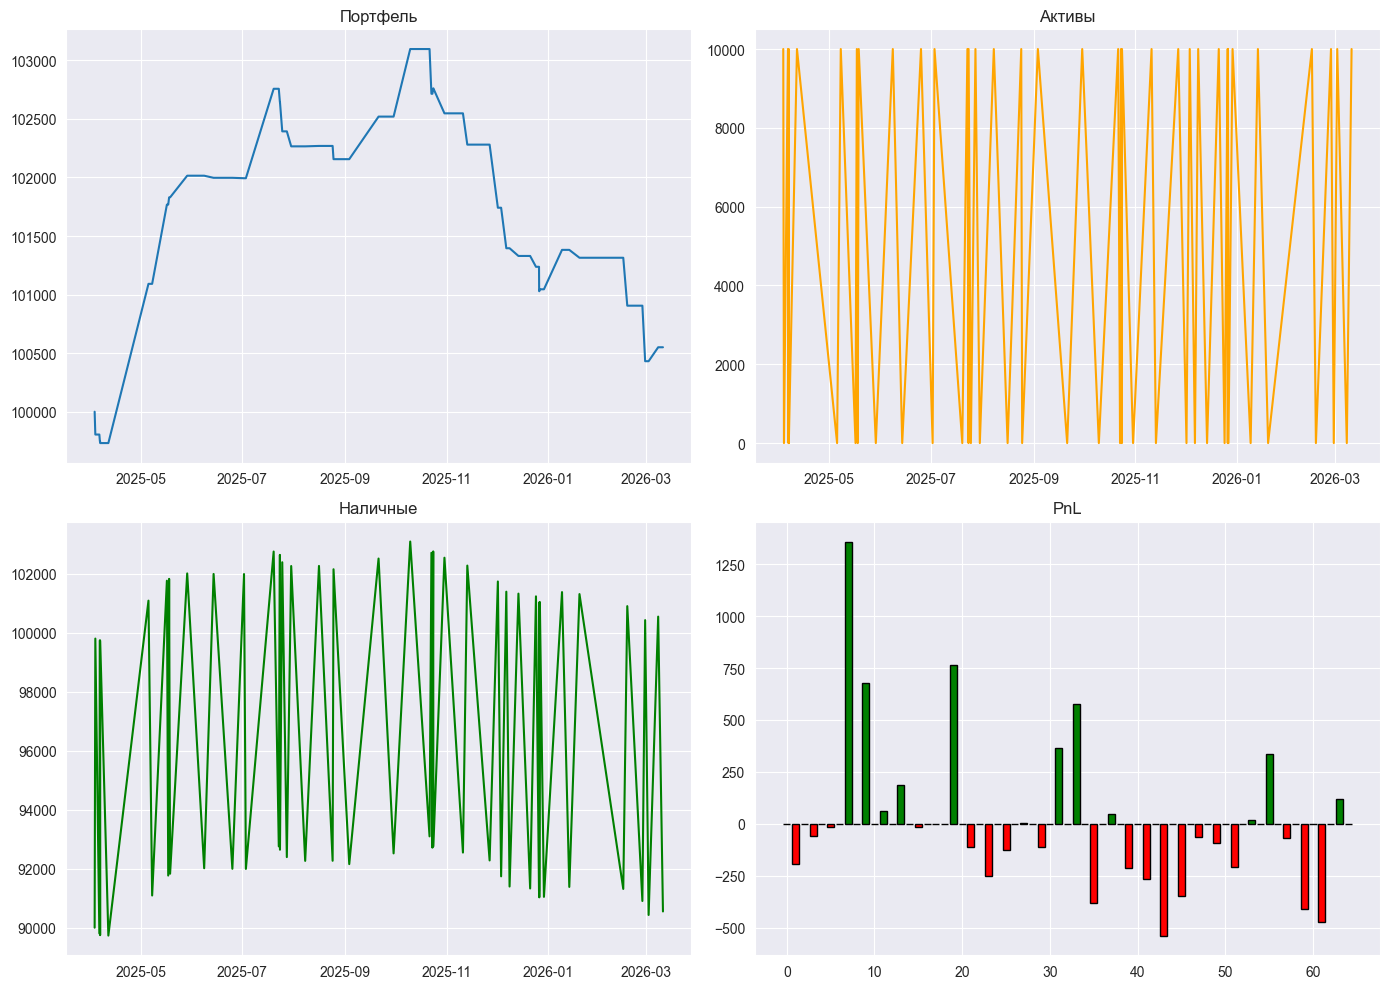

In [73]:
# Графики

fig, axs = plt.subplots(2, 2, figsize=(14, 10))  # 2×2 сетки

axs[0, 0].plot(trade_log_df.index, trade_log_df['portfolio'])
axs[0, 0].set_title('Портфель')
axs[0, 0].grid(True)

axs[0, 1].plot(trade_log_df.index, trade_log_df['investments'], color='orange')
axs[0, 1].set_title('Активы')
axs[0, 1].grid(True)

axs[1, 0].plot(trade_log_df.index, trade_log_df['cash'], color='green')
axs[1, 0].set_title('Наличные')
axs[1, 0].grid(True)

colors = ['green' if PnL >= 0 else 'red' for PnL in trade_log_df['PnL']]
axs[1, 1].bar(range(len(trade_log_df.index)), trade_log_df['PnL'], color=colors, edgecolor='black',)
axs[1, 1].set_title('PnL')
axs[1, 1].grid(True)

plt.tight_layout()
#plt.savefig(f'plots/{name}.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
#print(f"Графики успешно сохранены как 'plots/{name}.png'")

